# Trabajo Práctico 2 - Grupo 02

### Modelo BETO — Entrega N3

Integrantes:

*   Bermudez, Agustin
*   Calderón, Tiago
*   Gonzalez Pautaso, Mateo
*   Moreyra, Santiago
*   Nieves, Maylen

**Dataset:** Train aumentado con reseñas sintéticas generadas por LLM

**Hiperparámetros:** `lr=2e-05` | `epochs=3` | `max_length=128`

**Justificación:** Dataset aumentado con LLM. Ajustar el nombre del CSV si es distinto.

## 1. Instalación de dependencias

In [1]:
# Deep learning y transformers
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
!pip install transformers datasets accelerate

# NLP y preprocesamiento
!pip install spacy
!python -m spacy download es_core_news_sm

# ML clásico
!pip install scikit-learn xgboost joblib

# Data
!pip install pandas numpy scipy

# Visualización
!pip install matplotlib seaborn

# Análisis de sentimiento (SentiWordNet)
!pip install nltk

Looking in indexes: https://download.pytorch.org/whl/cu124
     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     -------------- ------------------------- 4.7/12.9 MB 57.1 MB/s eta 0:00:01
     --------------------------------------  12.8/12.9 MB 50.3 MB/s eta 0:00:01
     ---------------------------------------- 12.9/12.9 MB 40.3 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')


In [2]:
import nltk
nltk.download("sentiwordnet")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package sentiwordnet to
[nltk_data]     C:\Users\Valen\AppData\Roaming\nltk_data...
[nltk_data]   Package sentiwordnet is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Valen\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Valen\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## 2. Imports y configuración

In [3]:
import sys
sys.path.insert(0, "../../..")  # TP2/

import numpy as np
import pandas as pd
import torch
from pathlib import Path
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.metrics import f1_score, classification_report, confusion_matrix

from common.data_utils import get_split, SEED
from common.preprocessing import clean_minimal
from common.evaluation import evaluate

np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME  = "dccuchile/bert-base-spanish-wwm-cased"
MAX_LENGTH  = 128
BATCH_SIZE  = 32
NUM_EPOCHS  = 3
LR          = 2e-05
CLASS_NAMES = ["negativa", "neutra", "positiva"]

print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

c:\Users\Valen\Downloads\cdd\.venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 3060
VRAM: 12.9 GB


## 3. Carga de datos

In [4]:
train_df = pd.read_csv("../../../data/train_augmented_llm_balanced.csv")
test_df  = pd.read_csv("../../../data/test.csv")

print(f"Train: {len(train_df):,} filas")
print(f"Distribucion:\n{train_df['label'].value_counts().sort_index()}")

X_train_raw, X_val_raw, y_train, y_val = get_split(train_df)

print("\nAplicando clean_minimal...")
X_train = np.array([clean_minimal(t) for t in X_train_raw])
X_val   = np.array([clean_minimal(t) for t in X_val_raw])
X_test  = np.array([clean_minimal(t) for t in test_df["text"].values])
print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

Train: 66,553 filas
Distribucion:
label
0    22346
1    21864
2    22343
Name: count, dtype: int64

Aplicando clean_minimal...
Train: 53,242 | Val: 13,311 | Test: 8,500


## 4. Dataset y tokenización

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ResenasDataset(Dataset):
    def __init__(self, texts, labels=None, tokenizer=None, max_length=128):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = labels

    def __len__(self):
        return len(self.encodings["input_ids"])

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

print("Tokenizando...")
train_dataset = ResenasDataset(X_train, y_train, tokenizer, MAX_LENGTH)
val_dataset   = ResenasDataset(X_val,   y_val,   tokenizer, MAX_LENGTH)
test_dataset  = ResenasDataset(X_test,  None,    tokenizer, MAX_LENGTH)
print("Listo.")

Tokenizando...
Listo.


## 5. Modelo y métricas

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True,
)
model = model.to(DEVICE)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    f1_per = f1_score(labels, preds, average=None, zero_division=0)
    return {
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "f1_neg": float(f1_per[0]),
        "f1_neu": float(f1_per[1]),
        "f1_pos": float(f1_per[2]),
    }

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 39363.44it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from differe

## 6. Fine-tuning

In [7]:
OUTPUT_DIR = Path("models/red_neuronal_beto_v3_llm_augmented")

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LR,
    warmup_ratio=0.1,
    weight_decay=0.01,
    fp16=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=100,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f"Iniciando fine-tuning: lr={LR} | epochs={NUM_EPOCHS} | max_length={MAX_LENGTH}")
trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Iniciando fine-tuning: lr=2e-05 | epochs=3 | max_length=128


Epoch,Training Loss,Validation Loss,F1 Macro,F1 Neg,F1 Neu,F1 Pos
1,0.454176,0.443122,0.818048,0.839396,0.750665,0.864082
2,0.371235,0.442911,0.822966,0.843218,0.754907,0.870774
3,0.287925,0.508990,0.818916,0.837168,0.752629,0.866952


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.79it/s]


TrainOutput(global_step=4992, training_loss=0.39953331420054805, metrics={'train_runtime': 1053.5376, 'train_samples_per_second': 151.609, 'train_steps_per_second': 4.738, 'total_flos': 1.0506513440005632e+16, 'train_loss': 0.39953331420054805, 'epoch': 3.0})

## 7. Evaluación en validación

In [8]:
preds_output = trainer.predict(val_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)

evaluate("red_neuronal_beto_v3_llm_augmented", y_val, y_pred,
         hyperparams={
             "model": MODEL_NAME,
             "epochs": NUM_EPOCHS,
             "lr": LR,
             "max_length": MAX_LENGTH,
             "batch_size": BATCH_SIZE,
             "dataset": "llm_augmented",
         })


=== red_neuronal_beto_v3_llm_augmented ===
Hiperparámetros: {'model': 'dccuchile/bert-base-spanish-wwm-cased', 'epochs': 3, 'lr': 2e-05, 'max_length': 128, 'batch_size': 32, 'dataset': 'llm_augmented'}

F1-macro:  0.8230
Precision: 0.8237
Recall:    0.8241
Accuracy:  0.8248

              precision    recall  f1-score   support

    negativa     0.8137    0.8749    0.8432      4469
      neutra     0.7919    0.7212    0.7549      4373
    positiva     0.8656    0.8760    0.8708      4469

    accuracy                         0.8248     13311
   macro avg     0.8237    0.8241    0.8230     13311
weighted avg     0.8240    0.8248    0.8235     13311

Matriz de confusión (filas=real, cols=predicho):
          negativa  neutra  positiva
negativa      3910     451       108
neutra         719    3154       500
positiva       176     378      3915


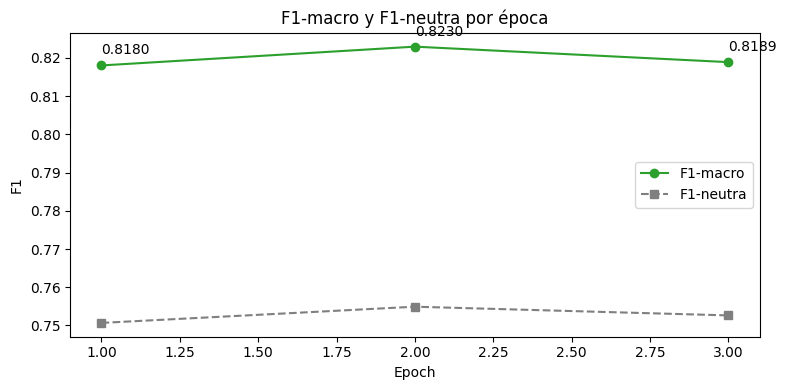

In [9]:
# Curva de entrenamiento
import matplotlib.pyplot as plt

history  = trainer.state.log_history
eval_f1  = [(x["epoch"], x["eval_f1_macro"]) for x in history if "eval_f1_macro" in x]
eval_neu = [(x["epoch"], x["eval_f1_neu"])   for x in history if "eval_f1_neu"   in x]

fig, ax = plt.subplots(figsize=(8, 4))
if eval_f1:
    epochs, f1s = zip(*eval_f1)
    ax.plot(epochs, f1s, marker="o", label="F1-macro", color="#2ca02c")
    for e, f in zip(epochs, f1s):
        ax.annotate(f"{f:.4f}", (e, f), textcoords="offset points", xytext=(0, 8))
if eval_neu:
    epochs, f1s = zip(*eval_neu)
    ax.plot(epochs, f1s, marker="s", label="F1-neutra", color="#7f7f7f", linestyle="--")
ax.set_xlabel("Epoch"); ax.set_ylabel("F1")
ax.set_title("F1-macro y F1-neutra por época")
ax.legend(); plt.tight_layout(); plt.show()

## 8. Guardado del modelo

In [10]:
SAVE_DIR = Path("models/red_neuronal_beto_v3_llm_augmented_final")
trainer.save_model(str(SAVE_DIR))
tokenizer.save_pretrained(str(SAVE_DIR))
print(f"Modelo guardado en {SAVE_DIR}")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.44it/s]

Modelo guardado en models\red_neuronal_beto_v3_llm_augmented_final


## 9. Submission a Kaggle

In [11]:
Path("submissions").mkdir(exist_ok=True)
preds_test  = trainer.predict(test_dataset)
y_test_pred = np.argmax(preds_test.predictions, axis=1)

sub = pd.DataFrame({"id": test_df["id"].values, "label": y_test_pred.astype(int)})
sub.to_csv("submissions/submission_red_neuronal_beto_v3_llm_augmented.csv", index=False)

dist = sub["label"].value_counts(normalize=True).sort_index()
print(f"Guardado: submissions/submission_red_neuronal_beto_v3_llm_augmented.csv  ({len(sub)} predicciones)")
print(f"Distribucion: {', '.join(f'clase {k}: {v:.1%}' for k, v in dist.items())}")

Guardado: submissions/submission_red_neuronal_beto_v3_llm_augmented.csv  (8500 predicciones)
Distribucion: clase 0: 43.1%, clase 1: 16.2%, clase 2: 40.6%
